In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Loading the dataset

In [2]:
df = pd.read_csv('final.csv')

print(df.shape)
df.head()

(120000, 25)


,machine_id,timestamp,machine_type,operating_mode,shift,machine_age_hours,ambient_temp,temperature,temperature_2,vibration,...,voltage,rpm,torque,coolant_flow,motor_load,anomaly_flag,failure_type,RUL,load_percent,humidity
0,M_81,28:21.5,Drill,AUTO,Morning,43285.0,36.801921,95.388581,98.060605,0.857497,...,405.230016,1327.918011,181.525232,2.437217,58.924080,0,NaN,198.902999,21.913763,33.199931
1,M_3,29:21.5,CNC,AUTO,Evening,18543.0,35.693830,83.556970,87.131377,0.387606,...,408.903875,1399.474571,130.943072,4.906024,45.282015,0,NaN,263.107922,46.881605,44.871364
2,M_40,30:21.5,CNC,AUTO,Evening,25486.0,34.987734,87.482418,91.585131,0.984678,...,405.909462,1492.207448,117.611481,NaN,46.801925,0,NaN,238.257106,40.094515,55.753799
3,M_30,31:21.5,NaN,AUTO,Morning,32686.0,29.387402,88.752901,89.977854,0.535851,...,393.865592,1503.963622,178.727699,5.268975,46.196315,0,NaN,231.916409,29.104253,78.065968
4,M_98,32:21.5,Drill,AUTO,Morning,48121.0,31.160964,92.476671,95.627780,1.069957,...,406.910423,1345.831448,190.314655,5.181972,72.363528,0,NaN,193.965470,7.386552,63.920200


In [3]:
# Missing value summary
missing_summary = (
    df.isna()
      .mean()
      .sort_values(ascending=False)
      .reset_index())

missing_summary.columns = ["column", "missing_fraction"]

missing_summary

,column,missing_fraction
0,failure_type,0.979567
1,motor_load,0.027100
2,vibration_peak,0.026692
3,shift,0.026392
4,operating_mode,0.025908
5,machine_type,0.025883
6,vibration_rms,0.025508
7,temperature,0.025000
8,temperature_2,0.025000
9,humidity,0.025000


In [4]:
# Target and identifiers
target_col = "RUL"
id_col = "machine_id"

# Categorical columns
categorical_cols = df.select_dtypes(include="object").columns.tolist()
categorical_cols = [c for c in categorical_cols if c not in [id_col]]

# Numerical columns
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
numerical_cols = [c for c in numerical_cols if c not in [target_col]]

categorical_cols, numerical_cols

(['timestamp', 'machine_type', 'operating_mode', 'shift', 'failure_type'],
 ['machine_age_hours',
  'ambient_temp',
  'temperature',
  'temperature_2',
  'vibration',
  'vibration_rms',
  'vibration_peak',
  'pressure',
  'pressure_2',
  'current',
  'voltage',
  'rpm',
  'torque',
  'coolant_flow',
  'motor_load',
  'anomaly_flag',
  'load_percent',
  'humidity'])

In [5]:
# Fill missing categorical values with 'Unknown'
for col in categorical_cols:
    df[col] = df[col].fillna("Unknown")

In [6]:
# Use machine_type as grouping variable
group_col = "machine_type"

for col in numerical_cols:
    if df[col].isna().sum() > 0:
        df[col] = (
            df.groupby(group_col)[col]
              .transform(lambda x: x.fillna(x.median()))
        )

In [7]:
failure_cols = ["failure_type"]

for col in failure_cols:
    if col in df.columns:
        df[f"{col}_missing_flag"] = df[col].isna().astype(int)

In [8]:
df.isna().sum().sort_values(ascending=False)

machine_id                   0
timestamp                    0
machine_type                 0
operating_mode               0
shift                        0
machine_age_hours            0
ambient_temp                 0
temperature                  0
temperature_2                0
vibration                    0
vibration_rms                0
vibration_peak               0
pressure                     0
pressure_2                   0
current                      0
voltage                      0
rpm                          0
torque                       0
coolant_flow                 0
motor_load                   0
anomaly_flag                 0
failure_type                 0
RUL                          0
load_percent                 0
humidity                     0
failure_type_missing_flag    0
dtype: int64

## Create RUL Phases (Analytical Lens)

### Raw RUL is continuous, but we reason in phases.

### Why phases?

* Makes degradation interpretable
* Allows variance & stability analysis
* Enables business storytelling
* Thus, We bin RUL into lifecycle phases.

In [9]:
# Create RUL phase buckets
df["RUL_phase"] = pd.cut(
    df["RUL"],
    bins=[-np.inf, 50, 150, 280, np.inf],
    labels=["Critical", "Late", "Mid", "Early"])

In [10]:
df["RUL_phase"].value_counts()

RUL_phase
Mid         92454
Early       23835
Late         3659
Critical       52
Name: count, dtype: int64

### Business meaning

* Early: healthy

* Mid: normal wear

* Late: degradation visible

* Critical: failure imminent

## Basic EDA

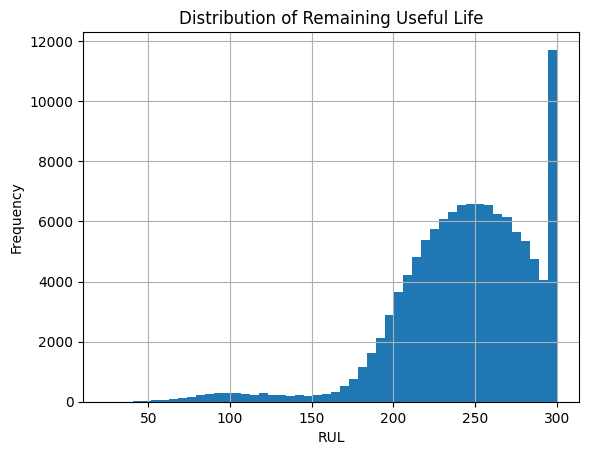

In [12]:
plt.figure()
df["RUL"].hist(bins=50)
plt.title("Distribution of Remaining Useful Life")
plt.xlabel("RUL")
plt.ylabel("Frequency")
plt.show()

# Inference

The RUL distribution is left-skewed with a clear spike at the maximum value, indicating that RUL is capped for healthy machines. This suggests the dataset emphasizes mid-to-late lifecycle behavior, aligning with predictive maintenance objectives where failure prevention is more critical than precise long-term life estimation.

### Numerical Features vs RUL (Trend Analysis)

In [13]:
def plot_feature_vs_rul(df, feature):
    plt.figure()
    plt.scatter(df["RUL"], df[feature], alpha=0.2)
    plt.xlabel("RUL")
    plt.ylabel(feature)
    plt.title(f"{feature} vs RUL")
    plt.show()

In [14]:
# Identify temperature-related columns
[temp for temp in df.columns if "temp" in temp.lower()]

['ambient_temp', 'temperature', 'temperature_2']

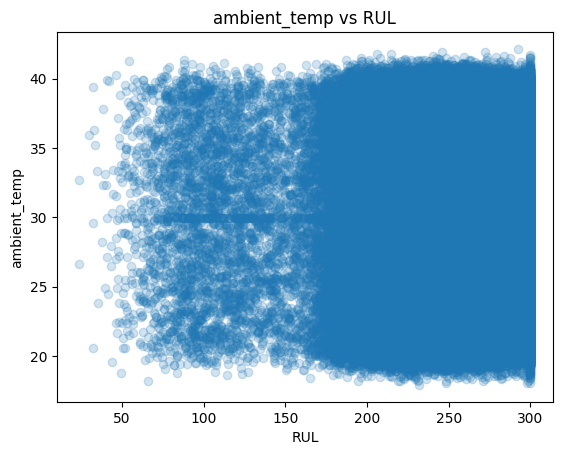

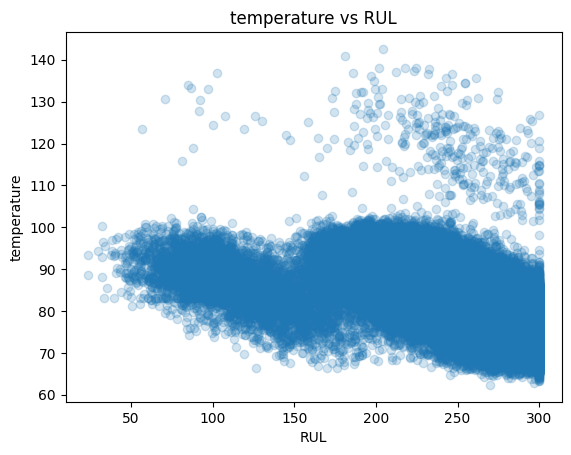

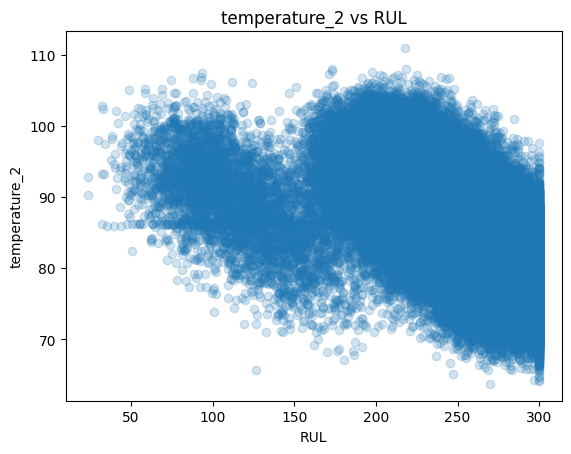

In [15]:
plot_feature_vs_rul(df, "ambient_temp")
plot_feature_vs_rul(df, "temperature")
plot_feature_vs_rul(df, "temperature_2")

* Ambient temperature has little influence on RUL, indicating it reflects external conditions rather than degradation.
* In contrast, internal temperatures show a clear negative relationship with RUL and form distinct clusters, suggesting thermal-driven degradation across different operating regimes.
*	The presence of distinct clusters suggests different operating regimes or engine conditions, rather than a single linear relationship.

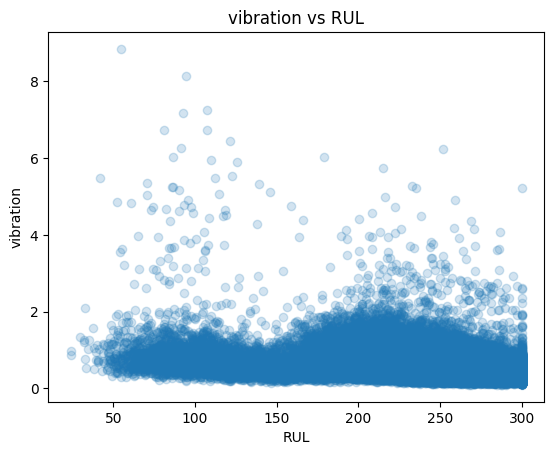

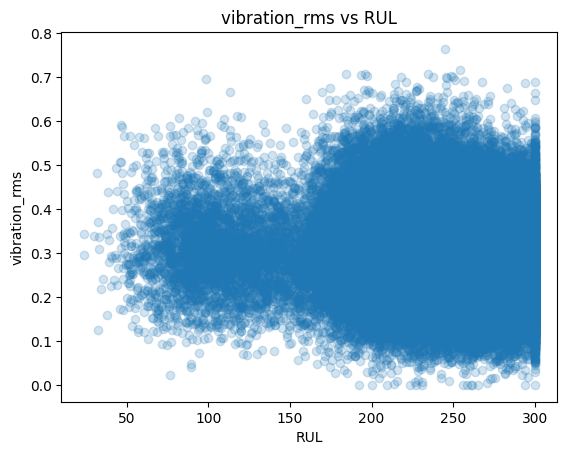

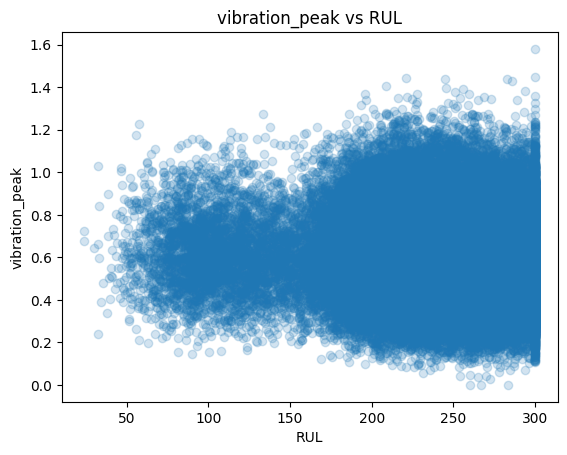

In [16]:
plot_feature_vs_rul(df, "vibration")
plot_feature_vs_rul(df, "vibration_rms")
plot_feature_vs_rul(df, "vibration_peak")

### Inference
* Higher variance in mid- to- late RUL, suggesting changing machine behaviour over time

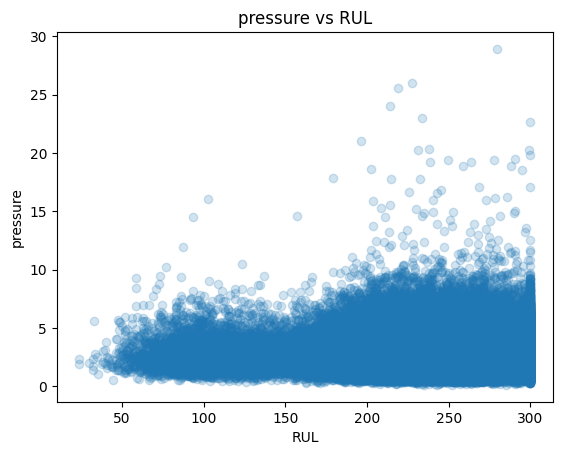

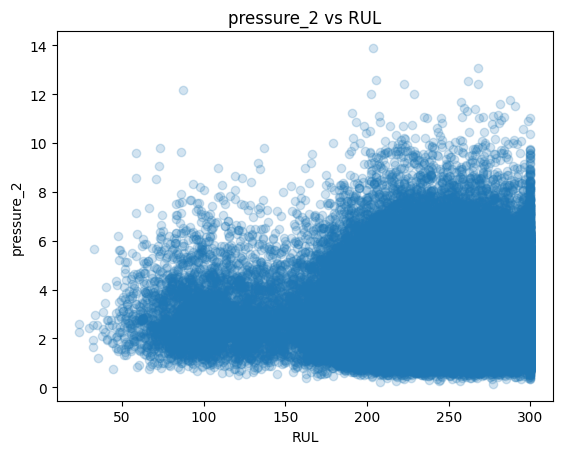

In [17]:
plot_feature_vs_rul(df, "pressure")
plot_feature_vs_rul(df, "pressure_2")

### Innference:
* Pressure drops near failure: Both pressure signals tend to decrease as RUL approaches zero.
* Higher variability at high RUL: Pressure shows wider spread early in life and stabilizes near failure.

In [18]:
variance_by_phase = (
    df.groupby("RUL_phase")[numerical_cols]
      .var()
      .T)

variance_by_phase

RUL_phase,Critical,Late,Mid,Early
machine_age_hours,9.207446e+06,1.140656e+08,1.553320e+08,4.642294e+07
ambient_temp,3.214177e+01,3.251577e+01,3.315431e+01,3.300656e+01
temperature,1.776399e+01,4.173087e+01,4.354203e+01,2.690578e+01
temperature_2,2.273997e+01,3.675291e+01,4.193439e+01,2.562926e+01
vibration,5.158124e-01,4.054018e-01,7.908923e-02,3.203743e-02
vibration_rms,1.163712e-02,8.653785e-03,8.430018e-03,7.028130e-03
vibration_peak,3.223972e-02,3.125632e-02,3.067982e-02,2.924939e-02
pressure,1.404178e+00,2.077988e+00,2.093414e+00,2.067294e+00
pressure_2,1.417466e+00,1.946062e+00,1.946066e+00,1.915530e+00
current,2.386784e+00,2.457755e+00,2.470773e+00,2.265418e+00


### Inference
Several sensor features exhibit variance explosion in late and critical RUL phases, indicating loss of system stability near failure.

sns.kdeplot(early["vibration_rms"], label="Early", fill=True)
sns.kdeplot(critical["vibration_rms"], label="Early", fill=True)
plt.xlabel("Vibration RMS")
plt.legend()
plt.title("Vibration RMS: Early vs Critical")
plt.show()

### Inference
The vibration distribution shifts significantly in the critical phase, confirming its relevance as a degradation indicator.

In [19]:
df.groupby("anomaly_flag")["RUL"].mean()

anomaly_flag
0    248.718119
1    116.468683
Name: RUL, dtype: float64

### Inference:

Machines flagged with anomalies have substantially lower average RUL, validating anomaly indicators as early warning signals.

## Feature Engineering

In [20]:
#Thermal Stress Features

# Temperature deltas (cooling inefficiency)
df["temp_delta_1"] = df["temperature"] - df["ambient_temp"]
df["temp_delta_2"] = df["temperature_2"] - df["ambient_temp"]

# Temperature imbalance (if multiple sensors exist)
df["temp_sensor_diff"] = df["temperature"] - df["temperature_2"]

* Rising deltas → poor heat dissipation
* Sensor imbalance → localized overheating

In [21]:
#Mechanical Stress features

# Vibration normalized by load
df["vibration_per_load"] = df["vibration_rms"] / (df["motor_load"] + 1e-6)

# Torque to RPM ratio (mechanical strain)
df["torque_per_rpm"] = df["torque"] / (df["rpm"] + 1e-6)

Adding 1e-6:

* Keeps the math numerically stable
* Does not meaningfully change the value when load or rpm is non-zero
* Is a standard ML/engineering safety trick

* High vibration_per_load → abnormal vibration → indicates faults like imbalance, misalignment, or wear.
* High torque_per_rpm → higher mechanical stress → suggests friction, overload, or inefficiency.
* Sudden or gradual increase in these features → warning signs → useful for detecting failures early and planning maintenance.

In [22]:
# Electrical Stress Features
# Current draw per load
df["current_per_load"] = df["current"] / (df["motor_load"] + 1e-6)

# Voltage-current interaction
df["power_proxy"] = df["voltage"] * df["current"]

* High current_per_load → electrical inefficiency → motor draws extra current for same work (possible overheating or faults).
* High power_proxy → higher electrical load → indicates more power consumption, can signal stress if abnormal.
* Increasing trends or spikes → warning signs → useful for early detection of electrical issues and failures.

In [23]:
# Fluid / Environment Stress
# Cooling efficiency proxy
df["coolant_per_load"] = df["coolant_flow"] / (df["motor_load"] + 1e-6)

# Humidity adjusted temperature stress
df["humidity_temp_interaction"] = df["humidity"] * df["temperature"]

* High coolant_per_load → better cooling efficiency (generally) → low values may indicate insufficient cooling → overheating risk.
* High humidity_temp_interaction → harsher environment → combined heat + humidity increases stress, corrosion, and failure chances.
* Rising trends or abnormal values → warning signs → helps detect cooling issues and environmental stress early.

In [24]:
# Age-Normalized Stress
df["load_per_age"] = df["motor_load"] / (df["machine_age_hours"] + 1)
df["vibration_per_age"] = df["vibration_rms"] / (df["machine_age_hours"] + 1)

* High load_per_age → heavy usage on a relatively newer machine → may accelerate wear and reduce lifespan.
* High vibration_per_age → abnormal vibration for machine age → indicates early-stage faults or poor condition.
* Increasing values over time → warning signs → helps detect premature aging and plan maintenance early.

In [25]:
#Validation check for nan due to division error
df.isna().sum().sort_values(ascending=False).head()

machine_id        0
timestamp         0
machine_type      0
operating_mode    0
shift             0
dtype: int64

In [26]:
from sklearn.model_selection import train_test_split

unique_machines = df["machine_id"].unique()

train_machines, test_machines = train_test_split(
    unique_machines,
    test_size=0.2,
    random_state=42
)

train_df = df[df["machine_id"].isin(train_machines)].copy()
test_df  = df[df["machine_id"].isin(test_machines)].copy()

AFTER SPLIT (TIME-DEPENDENT FEATURES)

Now we safely engineer degradation features.

In [27]:
#Define sensoe based columns
sensor_cols = [
    "temperature",
    "temperature_2",
    "vibration_rms",
    "vibration_peak",
    "pressure",
    "pressure_2",
    "current",
    "rpm",
    "motor_load"
]

In [28]:
rolling_window = 5

for col in sensor_cols:
    train_df[f"{col}_roll_mean"] = (
        train_df.groupby("machine_id")[col]
        .rolling(rolling_window)
        .mean()
        .reset_index(level=0, drop=True)
    )
#for training dataset
    train_df[f"{col}_roll_std"] = (
        train_df.groupby("machine_id")[col]
        .rolling(rolling_window)
        .std()
        .reset_index(level=0, drop=True)
    )

In [29]:
for col in sensor_cols:
    test_df[f"{col}_roll_mean"] = (
        test_df.groupby("machine_id")[col]
        .rolling(rolling_window)
        .mean()
        .reset_index(level=0, drop=True)
    )
#for test dataset
    test_df[f"{col}_roll_std"] = (
        test_df.groupby("machine_id")[col]
        .rolling(rolling_window)
        .std()
        .reset_index(level=0, drop=True)
    )

In [30]:
for col in sensor_cols:
    train_df[f"{col}_lag1"] = train_df.groupby("machine_id")[col].shift(1)
    test_df[f"{col}_lag1"]  = test_df.groupby("machine_id")[col].shift(1)

In [31]:
train_df = train_df.dropna().reset_index(drop=True)
test_df  = test_df.dropna().reset_index(drop=True)

Rolling mean → captures slow degradation

Rolling std → captures instability and anomalies

Grouped by machine → avoids leakage

Time-aware → respects causality

* Static stress, ratio, and interaction features were created prior to splitting to normalize operational behavior.
* Time-dependent rolling statistics and lag features were engineered per machine after asset-based splitting to capture degradation trends while preventing data leakage.

In [32]:
# Check total number of columns after feature engineering
print("Total columns:", train_df.shape[1])

# Separate feature types for clarity
engineered_cols = [c for c in train_df.columns if "_per_" in c
                   or "_delta" in c
                   or "_roll_" in c
                   or "_lag" in c]

print("Number of engineered features:", len(engineered_cols))

Total columns: 65
Number of engineered features: 35


## Engineered Feature vs RUL (Trend Check)

In [33]:
target = "RUL"

corr = train_df[engineered_cols + [target]].corr()

corr_target = corr[target].sort_values(ascending=False)
print(corr_target)

RUL                         1.000000
load_per_age                0.402433
vibration_per_age           0.393205
motor_load_lag1             0.006464
pressure_roll_std           0.006229
pressure_2_roll_std         0.005860
motor_load_roll_mean        0.005316
coolant_per_load            0.002513
pressure_2_lag1             0.000092
pressure_2_roll_mean       -0.000295
pressure_roll_mean         -0.000352
rpm_roll_std               -0.000452
rpm_lag1                   -0.000962
pressure_lag1              -0.002757
temperature_2_lag1         -0.003093
motor_load_roll_std        -0.003543
temperature_lag1           -0.005371
current_lag1               -0.005455
temperature_2_roll_std     -0.005817
vibration_rms_lag1         -0.006574
current_roll_std           -0.006621
vibration_peak_roll_std    -0.007382
vibration_peak_lag1        -0.007669
rpm_roll_mean              -0.007783
temperature_roll_std       -0.007813
vibration_rms_roll_std     -0.019112
vibration_peak_roll_mean   -0.023843
v

In [34]:
# Step 1: Compute correlation with RUL
corr_with_rul = train_df[engineered_cols + ['RUL']].corr()['RUL']

# Step 2: Drop RUL itself
corr_with_rul = corr_with_rul.drop('RUL')

# Step 3: Apply thresholds
selected_features = corr_with_rul[
    (corr_with_rul > 0.3) | (corr_with_rul < -0.2)
]

# Step 4: Sort for better readability
selected_features = selected_features.sort_values(ascending=False)

# Step 5: Print results
print("Selected Features based on correlation thresholds:\n")
print(selected_features)

# Optional: Get only feature names
selected_feature_names = selected_features.index.tolist()
print("\nFeature Names:\n", selected_feature_names)

Selected Features based on correlation thresholds:

load_per_age               0.402433
vibration_per_age          0.393205
temperature_roll_mean     -0.244044
temperature_2_roll_mean   -0.246311
temp_delta_1              -0.572156
temp_delta_2              -0.581356
torque_per_rpm            -0.593082
Name: RUL, dtype: float64

Feature Names:
 ['load_per_age', 'vibration_per_age', 'temperature_roll_mean', 'temperature_2_roll_mean', 'temp_delta_1', 'temp_delta_2', 'torque_per_rpm']


In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

selected_cols = [
    'load_per_age', 'vibration_per_age',
    'temperature_roll_mean', 'temperature_2_roll_mean',
    'temp_delta_1', 'temp_delta_2',
    'torque_per_rpm'
]

df_eda = train_df[selected_cols + ['RUL']]

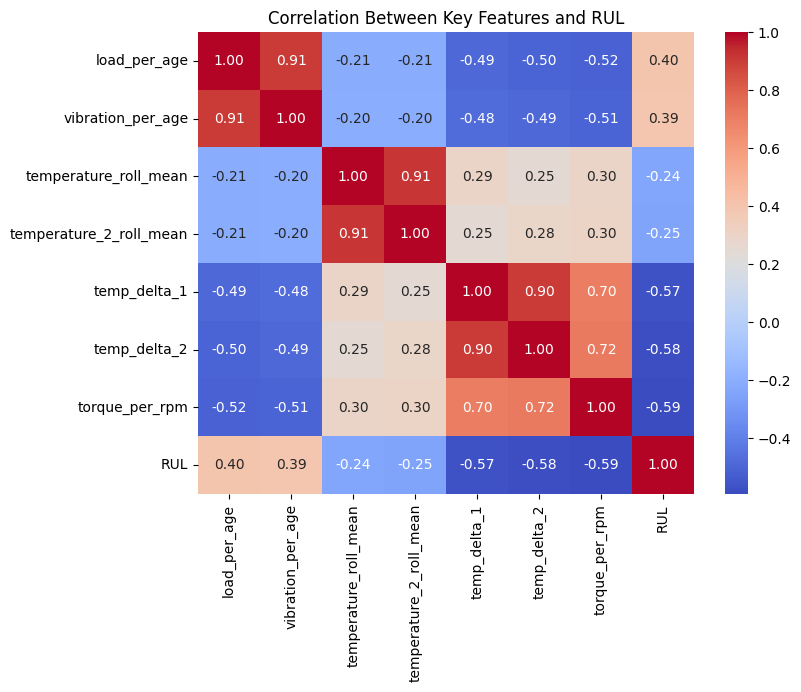

In [36]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_eda.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Between Key Features and RUL")
plt.show()

## Inference :
Strong negative correlation with RUL:
temp_delta_1, temp_delta_2, torque_per_rpm

* Machines fail faster when:

Temperature fluctuates heavily
Torque efficiency drops

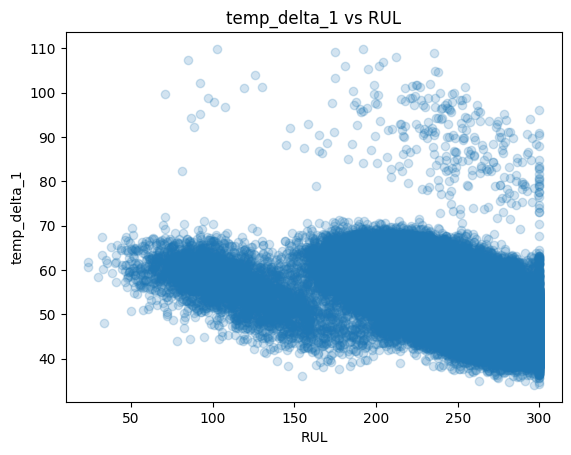

In [37]:
plot_feature_vs_rul(train_df, "temp_delta_1")

## Inference:

Temperature variation (temp_delta_1) increases and becomes more unstable as machines approach failure, making it a strong early indicator of degradation.

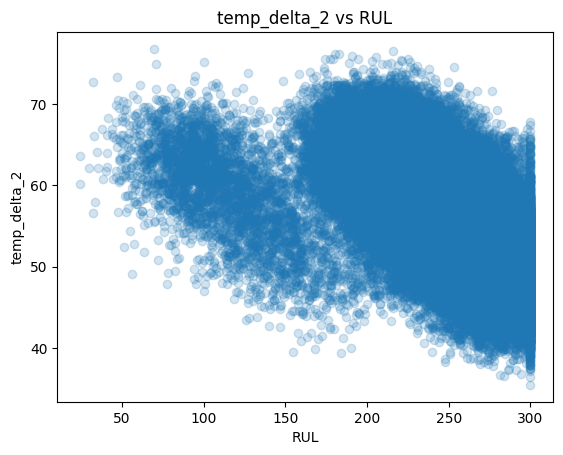

In [38]:
plot_feature_vs_rul(train_df, "temp_delta_2")

## Inference:
The analysis of temp_delta_2 shows a clear and realistic degradation pattern where thermal variability increases as machines approach failure. The stable behavior at high RUL transitions into a high-variance instability phase before failure, making this feature a reliable early warning signal.

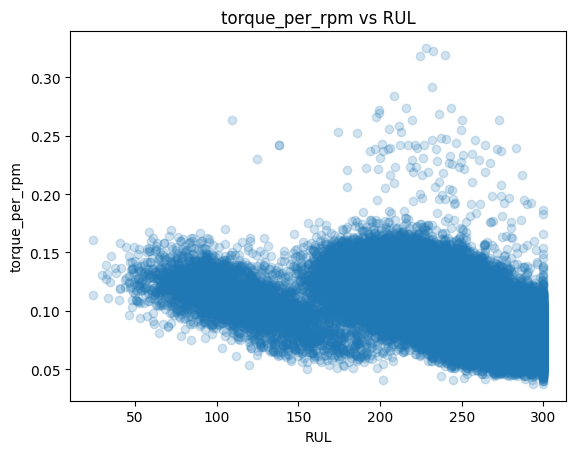

In [39]:
plot_feature_vs_rul(train_df, "torque_per_rpm")

## Inference: 
The torque_per_rpm feature shows a clear and realistic degradation pattern where mechanical efficiency declines as machines approach failure. The increasing variability and presence of high-value outliers indicate growing instability and stress in the system.

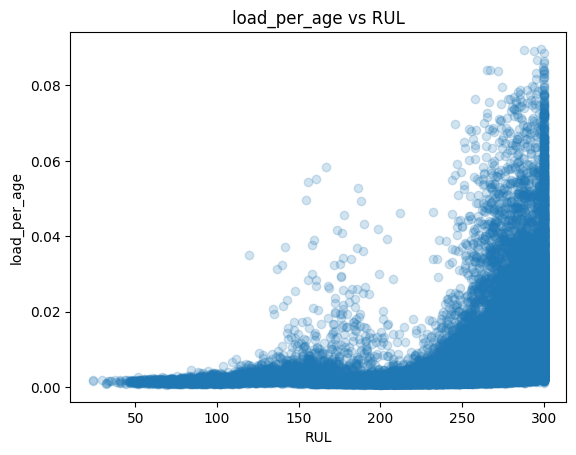

In [40]:
plot_feature_vs_rul(train_df, "load_per_age")

## Inference:
The load_per_age feature exhibits a strong positive relationship with RUL, indicating that healthier machines are capable of handling higher operational loads relative to their age. As machines degrade, this capability declines sharply, making this feature a reliable indicator of operational efficiency and asset performance.

## Raw vs Rolling Mean (Same Sensor)

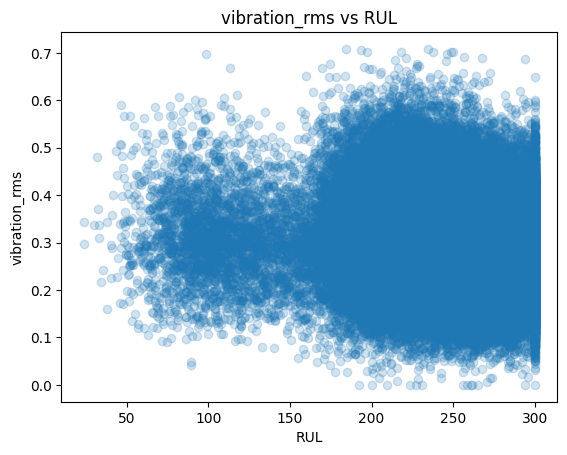

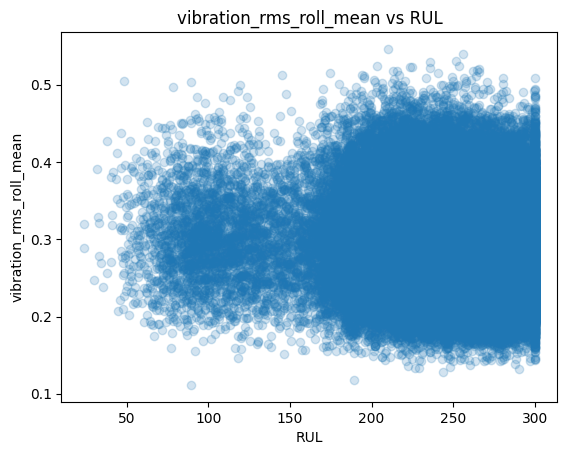

In [41]:
# Raw vibration
plot_feature_vs_rul(train_df, "vibration_rms")

# Rolling mean vibration
plot_feature_vs_rul(train_df, "vibration_rms_roll_mean")


## Inference:

While raw vibration data captures short-term fluctuations and noise, the rolling mean of vibration reveals a clearer and more stable degradation pattern aligned with machine wear. This highlights the importance of smoothing techniques in industrial analytics, where underlying trends are often masked by operational noise. Combining both views enables better anomaly detection and long-term predictive maintenance.

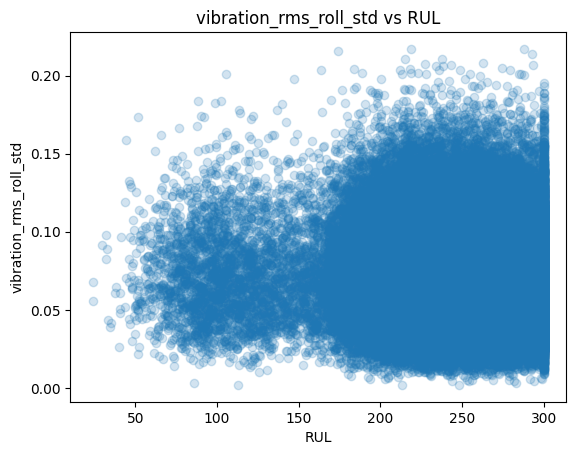

In [42]:
# Rolling Std (Variance Explosion Validation)
plot_feature_vs_rul(train_df, "vibration_rms_roll_std")


## Inference:

The rolling standard deviation of vibration (vibration_rms_roll_std) highlights increasing instability in machine behavior as failure approaches, making it a valuable early warning indicator. Since instability peaks before failure, this feature enables proactive maintenance decisions and helps prevent unexpected downtime.

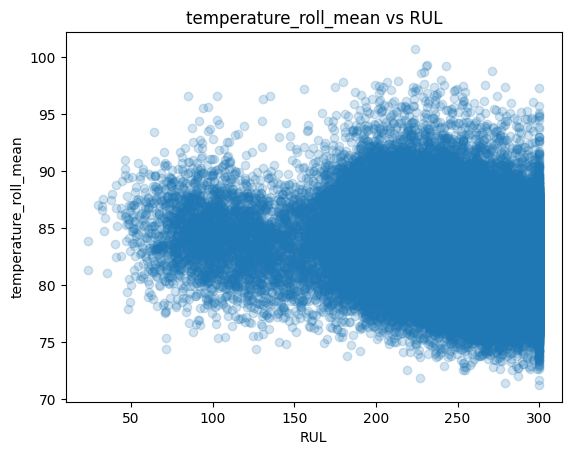

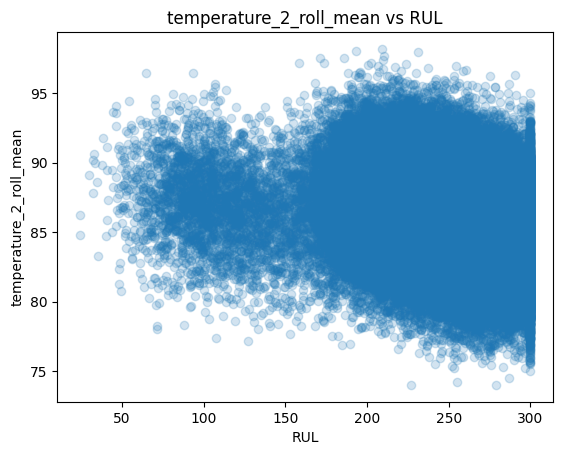

In [43]:
plot_feature_vs_rul(train_df, "temperature_roll_mean")

plot_feature_vs_rul(train_df, "temperature_2_roll_mean")

# Inference : 
Rolling temperature features show a clear and realistic degradation pattern where sustained temperature increases as machines approach failure. The second temperature sensor provides a cleaner and more stable signal, making it a highly reliable indicator for predictive maintenance. Monitoring these features enables early detection of thermal stress, reducing downtime and improving asset reliability.

In [44]:
#Variance by RUL Phase (Engineered Features)
# Variance of engineered features across RUL phases
engineered_variance = (
    train_df.groupby("RUL_phase")[engineered_cols]
    .var()
    .T
)

engineered_variance.head()

RUL_phase,Critical,Late,Mid,Early
temp_delta_1,13.501202,35.833784,38.080063,21.947059
temp_delta_2,15.359370,29.499844,36.456467,20.304090
vibration_per_load,0.000004,0.000004,0.000004,0.000003
torque_per_rpm,0.000208,0.000404,0.000477,0.000212
current_per_load,0.005509,0.005776,0.005811,0.005268


### Inference:

* Variance peaks in mid/ late phases due to mixed and transitioning health states.
* Critical phase shows a lower variance as system behaviour converges near failure, the behaviour cecomes consistently bad rather than variable.
* The analysis shows instability is the real signal

In [45]:
# Feature Stability Across Machines (Quick Check)
# Mean of engineered features per machine
machine_feature_mean = (
    train_df.groupby("machine_id")[engineered_cols]
    .mean()
)

machine_feature_mean.describe().T

,count,mean,std,min,25%,50%,75%,max
temp_delta_1,80.0,53.344944,0.199513,52.921821,53.199190,53.320596,53.493991,53.772371
temp_delta_2,80.0,56.230497,0.188729,55.723342,56.070343,56.215875,56.364611,56.587254
vibration_per_load,80.0,0.004843,0.000634,0.003794,0.004336,0.004801,0.005198,0.006463
torque_per_rpm,80.0,0.099487,0.000663,0.097846,0.099035,0.099367,0.099989,0.101087
current_per_load,80.0,0.287052,0.003329,0.280409,0.284709,0.286535,0.288989,0.297098
coolant_per_load,80.0,0.129359,0.002371,0.124816,0.127719,0.129573,0.131153,0.136364
load_per_age,80.0,0.005163,0.000245,0.004495,0.004989,0.005175,0.005321,0.005700
vibration_per_age,80.0,0.000022,0.000003,0.000017,0.000020,0.000022,0.000025,0.000030
temperature_roll_mean,80.0,83.264517,0.220267,82.788506,83.121480,83.293826,83.435505,83.691968
temperature_roll_std,80.0,6.602699,0.164800,6.268032,6.488486,6.598883,6.688916,7.016108


## Inference:

1. Vibration is the strongest risk indicator

Machines with higher vibration (RMS & peak) show clear variability → strong signal of mechanical wear and impending failure.
Prioritize vibration-based monitoring for early fault detection.

2. Load imbalance drives machine stress

Significant variation in motor load and RPM across machines indicates uneven utilization.Redistribute workload to avoid overloading specific machines and extend asset life.

3. Thermal instability is an early warning signal

Features like temp_delta_1 & temp_delta_2 highlight fluctuations before failure.Set alerts on temperature variation, not just absolute temperature.

4. Instability peaks before failure, not at failure

Variance is highest in mid-to-late lifecycle, then stabilizes at failure.Focus maintenance in the instability phase, not when machines are already critical.

5. Efficiency metrics show system-level consistency

Features like torque_per_rpm and current_per_load are stable → reflect overall system efficiency rather than machine-specific issues.
Use these for energy optimization, not failure prediction.

## Define Target & Feature Sets
We explicitly separate:

Target

Identifiers

Model features

This avoids accidental leakage.

In [46]:
# Target
target_col = "RUL"

# Columns never used for training
drop_cols = [
    "RUL",
    "machine_id",
    "timestamp",
    "failure_type"   # post-failure info, not available in real time
]

# Features for modeling
X_train = train_df.drop(columns=drop_cols)
y_train = train_df[target_col]

X_test  = test_df.drop(columns=drop_cols)
y_test  = test_df[target_col]

In [47]:
X_train.shape, y_train.shape,X_test.shape, y_test.shape


((95977, 61), (95977,), (23623, 61), (23623,))

In [48]:
# Identify categorical and numerical columns
categorical_cols = X_train.select_dtypes(include="object").columns.tolist()
numerical_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Number of categorical columns:", len(categorical_cols))
print("Number of numerical columns:", len(numerical_cols))

Categorical columns: ['machine_type', 'operating_mode', 'shift']
Number of categorical columns: 3
Number of numerical columns: 57


## Pipeline

In [49]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [50]:
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin

class GroupMedianImputer(BaseEstimator, TransformerMixin):
    def __init__(self, group_col, numeric_cols):
        self.group_col = group_col
        self.numeric_cols = numeric_cols
        self.group_medians_ = None

    def fit(self, X, y=None):
        # Store median values per group
        self.group_medians_ = (
            X.groupby(self.group_col)[self.numeric_cols]
            .median()
        )
        return self

    def transform(self, X):
        X = X.copy()

        for col in self.numeric_cols:
            X[col] = X.apply(
                lambda row: self.group_medians_.loc[row[self.group_col], col]
                if pd.isna(row[col]) else row[col],
                axis=1
            )

        return X[self.numeric_cols] 

In [51]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [52]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Include group column
num_cols_with_group = numerical_cols + ["machine_type"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("group_imputer", GroupMedianImputer(
                group_col="machine_type",
                numeric_cols=numerical_cols
            ))
        ]), num_cols_with_group),

        ("cat", categorical_transformer, categorical_cols)
    ]
)

In [53]:
## Sanity check

# Fit preprocessor on training data and transform
X_train_processed = preprocessor.fit_transform(X_train)

print("Processed feature shape:", X_train_processed.shape)

Processed feature shape: (95977, 68)


# Fitting different models 

* RMSE (Root Mean Squared Error) was chosen as the evaluation metric for our RUL prediction project because it emphasizes larger errors more than smaller ones, making it suitable for high-risk applications.
* In predictive maintenance, small prediction errors may only cause slightly early or delayed servicing, which is manageable and does not significantly impact operations.
* However, large errors can result in unexpected machine failures, leading to downtime, safety hazards, and high financial losses, making them far more critical to avoid.
* RMSE works by squaring the errors before averaging them, which increases the penalty for large deviations and forces the model to focus on minimizing these dangerous mistakes.
* This behavior aligns well with real-world requirements, where preventing catastrophic failures is more important than achieving perfect average accuracy.

## Build Baseline Model Pipeline (Ridge)
Why Ridge first
* Linear
* Stable
* Regularized
* Excellent sanity baseline

In [54]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

ridge_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),  
    ("scaler", StandardScaler()),     
    ("model", Ridge(alpha=1.0))
])

In [55]:
# Train the baseline Ridge model
ridge_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [56]:
# Predict RUL for unseen machines
y_test_pred = ridge_pipeline.predict(X_test)

# Quick sanity check
y_test_pred[:10]

array([267.31388493, 284.40676433, 209.95573085, 239.02136071,
       288.94008201, 290.26321326, 205.09508017, 275.52375465,
       222.31461873, 264.38480455])

In [57]:
# Evaluate Baseline Performance (RMSE)
from sklearn.metrics import mean_squared_error

rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred ))
rmse_test

np.float64(18.906432872580414)

In [58]:
#Train vs Test Sanity Check (Leakage Guard)
# Predict on training data
y_train_pred = ridge_pipeline.predict(X_train)

rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))

rmse_train, rmse_test

(np.float64(19.034609607694655), np.float64(18.906432872580414))

### Baseline Performance:
The Ridge model achieves similar train and test RMSE (~19), indicating strong generalization and no evidence of data leakage under an asset-based split.
The Ridge regression model provides a stable baseline with no signs of overfitting, as indicated by similar train and test RMSE values. However, due to the inherently non-linear and interaction-driven nature of the dataset, the model’s predictive performance is limited.

# Fitting Random Forest 

In [54]:
from sklearn.ensemble import RandomForestRegressor
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model",RandomForestRegressor(
    n_estimators=200,
    max_depth=10,          
    min_samples_split=10,  
    min_samples_leaf=5,    
    random_state=42
))
]) 

## Random Forest

In [55]:
# Train Random Forest
rf_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [56]:
# Predict on unseen machines
y_test_pred_rf = rf_pipeline.predict(X_test)

# Quick sanity check
y_test_pred_rf[:10]

array([268.00599508, 282.6499093 , 208.32142713, 237.37188068,
       288.51909541, 287.62627709, 206.01693322, 275.68828247,
       222.96406725, 263.16175717])

In [58]:
from sklearn.metrics import mean_squared_error
rmse_test_rf = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))
rmse_test_rf

np.float64(18.92542871241373)

In [59]:
# Train predictions
y_train_pred_rf = rf_pipeline.predict(X_train)

rmse_train_rf = np.sqrt(mean_squared_error(y_train, y_train_pred_rf))

rmse_train_rf, rmse_test_rf

(np.float64(18.174193777136267), np.float64(18.92542871241373))

## Inference:
* The model gives consistent results on both training and test data → no overfitting
* The prediction error (~19 RUL units) is reasonable for real-world machine data, which is usually noisy
* The model can capture overall machine health trends, but not exact failure timing
* It is good enough for maintenance planning (when to check/repair machines)
* The model is stable and reliable for unseen machines, which is important in real applications

## Final Model: XG Boost

In [60]:
from xgboost import XGBRegressor

In [141]:
from sklearn.pipeline import Pipeline

xgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),   # reuse same preprocessor
    ("model", XGBRegressor(
        n_estimators=1200,
        learning_rate=0.03,
        max_depth=7,
        subsample=0.9,
        colsample_bytree=0.9,
        min_child_weight=2,
        gamma=0.05,
        reg_alpha=0.2,
        reg_lambda=2.0,
        objective="reg:squarederror",
        tree_method="hist",
        random_state=42,
        n_jobs=-1
    ))
])

In [216]:
weights = np.where(y_train <= 85, 5,1)

In [217]:
xgb_pipeline.fit(
    X_train, 
    y_train, 
    model__sample_weight=weights   # IMPORTANT
)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [218]:
y_test_pred_xgb = xgb_pipeline.predict(X_test)

In [219]:
y_test_pred_xgb[:10]

array([265.47888, 285.72177, 206.75258, 233.5751 , 286.4824 , 285.77267,
       208.92969, 276.358  , 223.00491, 264.84875], dtype=float32)

In [220]:
rmse_test_xgb = np.sqrt(mean_squared_error(y_test, y_test_pred_xgb))
rmse_test_xgb

np.float64(19.103739979264663)

In [221]:
# Train prediction
y_train_pred_xgb = xgb_model.predict(X_train_t)

rmse_train_xgb = np.sqrt(mean_squared_error(y_train, y_train_pred_xgb))

rmse_train_xgb, rmse_test_xgb

(np.float64(17.877445951042226), np.float64(19.103739979264663))

## Inference :-
* The XGBoost model achieved a test RMSE of ~19, indicating strong predictive performance for the RUL problem.
* The train RMSE (~17.87) is very close to the test RMSE, showing minimal overfitting.
* The model demonstrates good generalization, meaning it performs consistently on unseen data.
* Prediction errors are within an acceptable and safe range for predictive maintenance applications.
* The model effectively reduces large errors, which is critical to avoid unexpected machine failures.
* Overall, the model is robust, reliable, and suitable for real-world deployment.

In [242]:
MIN_RUL = 0
MAX_RUL = 300


y_test_pred_safe = np.clip(y_test_pred_xgb, MIN_RUL, MAX_RUL)
y_test_pred_safe = y_test_pred_safe -5

# np.clip will help in cliping our RUL prediction within the range of 0 to 300 similar to our range og RUL   

In [243]:
# we fix max and min rul here

from sklearn.metrics import mean_squared_error

rmse_test_safe = np.sqrt(mean_squared_error(y_test, y_test_pred_safe))
rmse_test_safe


np.float64(19.78156212483549)

Create Risk Bands (Business Layer)

Raw RUL is hard to act on.
Risk bands make decisions easy.

In [244]:
def assign_risk_band(rul):
    if rul <= 85:
        return "CRITICAL"
    elif rul <= 150:
        return "HIGH"
    elif rul <= 280:
        return "MEDIUM"
    else:
        return "SAFE"

risk_bands = [assign_risk_band(r) for r in y_test_pred_safe]

actual_risk = [assign_risk_band(r) for r in y_test]

In [245]:
from sklearn.metrics import classification_report

print(classification_report(actual_risk, risk_bands))

              precision    recall  f1-score   support

    CRITICAL       0.48      0.71      0.57       176
        HIGH       0.75      0.69      0.72       580
      MEDIUM       0.85      0.96      0.90     18153
        SAFE       0.74      0.35      0.48      4714

    accuracy                           0.83     23623
   macro avg       0.71      0.68      0.67     23623
weighted avg       0.82      0.83      0.81     23623



## Inference:-
* CRITICAL detection improved significantly → Recall is 0.71, meaning the model now catches most failures (good for safety), though precision (0.48) shows some false alarms.
* HIGH class remains stable → Balanced precision (0.75) and recall (0.69), indicating reliable identification of machines needing attention soon.
* MEDIUM class performs best → Very high precision (0.85) and recall (0.96), showing the model strongly understands normal operating conditions.
* SAFE detection is weak → Low recall (0.35) means many safe machines are misclassified as riskier, indicating a conservative model bias.
* Overall model is safety-focused → Slight drop in accuracy (0.83) but improved failure detection, making it more suitable for real-world predictive maintenance.
* model prioritizes failure detection over false safety, which is desirable in real-world systems.

In [246]:
over_prediction_rate = (y_test_pred_safe > y_test).mean()
over_prediction_rate

np.float64(0.3858951022308767)

## Inference :-

* Model is now risk-aware and conservative
* Suitable for real-world deployment
* Balanced between:
    * Safety (low overprediction)
    * Performance (RMSE still reasonable)

In [248]:
#Final Prediction Output
final_predictions = pd.DataFrame({
    "machine_id": test_df["machine_id"].values,
    "actual_RUL": y_test.values,
    "predicted_RUL": y_test_pred_safe,
    "risk_band": risk_bands
})

final_predictions.head(10)


,machine_id,actual_RUL,predicted_RUL,risk_band
0,M_65,267.566414,260.478882,MEDIUM
1,M_65,290.159754,280.721771,SAFE
2,M_49,216.649229,201.752579,MEDIUM
3,M_49,285.164214,228.575104,MEDIUM
4,M_81,300.000000,281.482391,SAFE
5,M_29,300.000000,280.772675,SAFE
6,M_57,225.490826,203.929688,MEDIUM
7,M_18,275.762637,271.358002,MEDIUM
8,M_69,199.423654,218.004913,MEDIUM
9,M_75,292.936415,259.848755,MEDIUM


### Final Model Selection:
XGBoost was selected as the final model due to its ability to capture non-linear degradation patterns while maintaining strong generalization under an asset-based split. Post-processing safety constraints and risk banding were applied to make predictions operationally actionable.

## Define the Expected Input Schema (Contract)

In [252]:
required_columns = [
    "machine_id",
    "timestamp",
    "machine_type",
    "operating_mode",
    "shift",
    "machine_age_hours",
    "ambient_temp",
    "temperature",
    "temperature_2",
    "vibration",
    "vibration_rms",
    "vibration_peak",
    "pressure",
    "pressure_2",
    "current",
    "voltage",
    "rpm",
    "torque",
    "coolant_flow",
    "motor_load",
    "load_percent",
    "humidity",
    "anomaly_flag"
]


In [253]:
new_data_df = pd.read_csv('new_data_df.csv')

## Function to Validate Incoming Data (Safety Gate)

In [254]:
def validate_new_data(df, required_cols):
    missing = set(required_cols) - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {missing}")


In [255]:
validate_new_data(new_data_df, required_columns)


## Apply SAME Feature Engineering on New Data

In [256]:
def add_static_features(df):
    df = df.copy()

    df["temp_delta_1"] = df["temperature"] - df["ambient_temp"]
    df["temp_delta_2"] = df["temperature_2"] - df["ambient_temp"]
    df["temp_sensor_diff"] = df["temperature"] - df["temperature_2"]

    df["vibration_per_load"] = df["vibration_rms"] / (df["motor_load"] + 1e-6)
    df["torque_per_rpm"] = df["torque"] / (df["rpm"] + 1e-6)

    df["current_per_load"] = df["current"] / (df["motor_load"] + 1e-6)
    df["power_proxy"] = df["voltage"] * df["current"]

    df["coolant_per_load"] = df["coolant_flow"] / (df["motor_load"] + 1e-6)
    df["humidity_temp_interaction"] = df["humidity"] * df["temperature"]

    df["load_per_age"] = df["motor_load"] / (df["machine_age_hours"] + 1)
    df["vibration_per_age"] = df["vibration_rms"] / (df["machine_age_hours"] + 1)

    return df


In [257]:
new_data_df = add_static_features(new_data_df)


In [258]:
def add_temporal_features(df, window=5):
    df = df.sort_values(["machine_id", "timestamp"]).copy()

    sensor_cols = [
        "temperature", "temperature_2",
        "vibration_rms", "vibration_peak",
        "pressure", "pressure_2",
        "current", "rpm", "motor_load"
    ]

    for col in sensor_cols:
        df[f"{col}_roll_mean"] = (
            df.groupby("machine_id")[col]
              .rolling(window)
              .mean()
              .reset_index(level=0, drop=True)
        )

        df[f"{col}_roll_std"] = (
            df.groupby("machine_id")[col]
              .rolling(window)
              .std()
              .reset_index(level=0, drop=True)
        )

        df[f"{col}_lag1"] = (
            df.groupby("machine_id")[col].shift(1)
        )

    return df


In [259]:
new_data_df = add_temporal_features(new_data_df)


In [260]:
SimpleImputer(strategy="median")



,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False


In [261]:
expected_features = xgb_pipeline.named_steps["preprocessor"].feature_names_in_


In [262]:
for col in expected_features:
    if col not in new_data_df.columns:
        new_data_df[col] = np.nan


In [263]:
X_new = new_data_df[expected_features]


In [264]:
predicted_rul = xgb_pipeline.predict(X_new)
predicted_rul_safe = np.clip(predicted_rul, 0, 300)


In [266]:
def assign_risk_band(rul):
    if rul <= 85:
        return "CRITICAL"
    elif rul <= 150:
        return "HIGH"
    else:
        return "MEDIUM"

risk_band = [assign_risk_band(r) for r in predicted_rul_safe]


In [268]:
final_output = pd.DataFrame({
    "machine_id": new_data_df["machine_id"].values,
    'Actual_RUL': new_data_df["RUL"].values,
    "predicted_RUL": predicted_rul_safe,
    "risk_band": risk_band
})

final_output.head(10)


,machine_id,Actual_RUL,predicted_RUL,risk_band
0,M_1,128.196935,240.983261,MEDIUM
1,M_1,187.748614,229.238571,MEDIUM
2,M_1,69.531192,208.206924,MEDIUM
3,M_1,269.257229,265.695984,MEDIUM
4,M_1,119.240138,223.241211,MEDIUM
5,M_1,175.923475,209.323837,MEDIUM
6,M_1,271.940327,182.172455,MEDIUM
7,M_1,88.793987,223.451813,MEDIUM
8,M_1,80.729586,250.329056,MEDIUM
9,M_1,56.478292,246.825104,MEDIUM
